# SEP Occurrence Forecasting — Native PyTorch

This research-style workflow uses the archived train/test pickles exactly
as supplied. The 49 predictors are anonymous, and the archive has no event IDs
or timestamps. Consequently, this is sample-level teaching evidence: it cannot
establish event-aware generalization or physical feature attribution.

In Colab, choose **Runtime → Run all**; the bootstrap downloads and verifies
only four pickles.

## Runtime dependency check

In [1]:
import importlib.util
import subprocess
import sys
from pathlib import Path

REQUIRED_RUNTIME = {'torch': 'torch'}
COLAB_EXTRAS = {}
missing_required = [
    package for module, package in REQUIRED_RUNTIME.items()
    if importlib.util.find_spec(module) is None
]
missing_extras = [
    package for module, package in COLAB_EXTRAS.items()
    if importlib.util.find_spec(module) is None
]
if missing_extras and "google.colab" in sys.modules:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", *missing_extras]
    )
    missing_extras = []
if missing_required or missing_extras:
    missing = ", ".join(missing_required + missing_extras)
    raise RuntimeError(
        f"Missing notebook dependencies: {missing}. Locally run "
        "`uv sync --group notebooks`; in Colab restart the runtime if an "
        "installation cell just changed the environment."
    )
print("runtime dependency check passed")

runtime dependency check passed


In [2]:
%matplotlib inline

## Imports and deterministic configuration

These tools handle the tabular archive, preprocessing, classification metrics,
and figures. The fixed seed keeps the sample-level comparison reproducible.

In [3]:
import json
import os
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

## Resolve the immutable archive

The four supplied files contain the archived training and test samples. Their
checksums are verified so every implementation starts from the same data.

In [4]:
import hashlib
import os
from pathlib import Path
from urllib.parse import quote
from urllib.request import urlopen

DATASET_ID = 'sep-curated'
DATASET_FILES = {'x_train.pkl': ('data/sep-curated/x_train.pkl', 'e809bf00498633f509a223d61f9b0006e6ed1803f6de22118bcf654f2ce8ba3b'), 'x_test.pkl': ('data/sep-curated/x_test.pkl', '1d0c5f84713d4fde34d567cdb62e9081c4d723f6fef9abd543137376350d5955'), 'y_train.pkl': ('data/sep-curated/y_train.pkl', 'd7aa048f6b081a9fb1fc00dde19872c0f67ae5b4c8620daa5984b679f9f9dbdc'), 'y_test.pkl': ('data/sep-curated/y_test.pkl', 'd44c5af108bab2b19f5f8082548282edd8aee89d57e15469516de1ca3f400ee5')}


def file_sha256(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def resolve_dataset():
    resolved = {}
    override = os.getenv("HELIO_DATA_DIR")
    cache_root = Path(
        os.getenv("HELIO_DATA_CACHE", Path.home() / ".cache" / "helio-data-methods")
    ) / "datasets" / DATASET_ID
    for filename, (relative_path, checksum) in DATASET_FILES.items():
        candidates = []
        if override:
            root = Path(override).expanduser()
            candidates.extend([root / DATASET_ID / filename, root / filename])
        for root in [Path.cwd(), *Path.cwd().parents]:
            candidates.append(root / relative_path)
        target = cache_root / filename
        candidates.append(target)
        match = next(
            (
                candidate
                for candidate in candidates
                if candidate.is_file() and file_sha256(candidate) == checksum
            ),
            None,
        )
        if match is None:
            target.parent.mkdir(parents=True, exist_ok=True)
            ref = os.getenv("HELIO_DATA_REF", "main")
            url = (
                "https://raw.githubusercontent.com/SavvasRaptis/helio-data-methods/"
                f"{quote(ref, safe='')}/{quote(relative_path, safe='/')}"
            )
            try:
                with urlopen(url, timeout=120) as response, target.open("wb") as output:
                    while chunk := response.read(1024 * 1024):
                        output.write(chunk)
            except Exception as exc:
                target.unlink(missing_ok=True)
                raise RuntimeError(
                    f"Could not retrieve {DATASET_ID}/{filename}. Check network "
                    "access or set HELIO_DATA_DIR to the archived data directory."
                ) from exc
            if file_sha256(target) != checksum:
                target.unlink(missing_ok=True)
                raise ValueError(
                    f"Checksum mismatch for {DATASET_ID}/{filename}; "
                    "the invalid download was removed."
                )
            match = target
        resolved[filename] = match
    return resolved


dataset_files = resolve_dataset()
print("verified dataset:", DATASET_ID)
for name in dataset_files:
    print(f"  {name} (checksum verified)")

verified dataset: sep-curated
  x_train.pkl: data/sep-curated/x_train.pkl
  x_test.pkl: data/sep-curated/x_test.pkl
  y_train.pkl: data/sep-curated/y_train.pkl
  y_test.pkl: data/sep-curated/y_test.pkl


## Preserve the supplied test set and split training samples

The supplied test set remains untouched. A stratified part of the supplied
training samples is reserved for validation, and scaling is fitted only on the
remaining training samples.

In [5]:
x_supplied_train = pd.read_pickle(dataset_files["x_train.pkl"]).to_numpy(dtype=np.float32)
x_test = pd.read_pickle(dataset_files["x_test.pkl"]).to_numpy(dtype=np.float32)
y_supplied_train = (
    pd.read_pickle(dataset_files["y_train.pkl"]).to_numpy().reshape(-1).astype(np.int64)
)
y_test = pd.read_pickle(dataset_files["y_test.pkl"]).to_numpy().reshape(-1).astype(np.int64)
feature_names = np.asarray([f"anonymous feature {i}" for i in range(x_test.shape[1])])

train_indices, validation_indices = train_test_split(
    np.arange(len(y_supplied_train)),
    test_size=0.15,
    random_state=SEED,
    stratify=y_supplied_train,
)
x_train_raw = x_supplied_train[train_indices]
y_train = y_supplied_train[train_indices]
x_validation_raw = x_supplied_train[validation_indices]
y_validation = y_supplied_train[validation_indices]
scaler = StandardScaler().fit(x_train_raw)
x_train = scaler.transform(x_train_raw).astype(np.float32)
x_validation = scaler.transform(x_validation_raw).astype(np.float32)
x_test_scaled = scaler.transform(x_test).astype(np.float32)

counts = np.bincount(y_train, minlength=2)
majority_class = int(np.argmax(counts))
majority_prediction = np.full_like(y_test, majority_class)
class_weights = len(y_train) / (2.0 * np.maximum(counts, 1))
print(
    f"train={len(y_train):,}, validation={len(y_validation):,}, "
    f"supplied test={len(y_test):,}, positive prevalence={y_train.mean():.4f}"
)
print("class weights:", dict(enumerate(class_weights.round(3))))

train=13,846, validation=2,444, supplied test=1,811, positive prevalence=0.0125
class weights: {0: 0.506, 1: 40.017}


## Establish the majority-class baseline

SEP occurrences are rare in this archive, so overall accuracy alone can be
misleading. The majority-class result provides context for the imbalance-aware
metrics used below.

In [6]:
def classification_evidence(y_true, probability, label):
    prediction = (probability >= 0.5).astype(np.int64)
    evidence = {
        "accuracy": float(accuracy_score(y_true, prediction)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, prediction)),
        "roc_auc": float(roc_auc_score(y_true, probability)),
        "pr_auc": float(average_precision_score(y_true, probability)),
        "confusion_matrix": confusion_matrix(y_true, prediction, labels=[0, 1]).tolist(),
    }
    print(label, json.dumps(evidence, indent=2))
    print(classification_report(y_true, prediction, digits=3, zero_division=0))
    return evidence


majority_probability = np.full(len(y_test), float(majority_class))
majority_evidence = classification_evidence(
    y_test, majority_probability, "majority-class baseline"
)

majority-class baseline {
  "accuracy": 0.9872998343456654,
  "balanced_accuracy": 0.5,
  "roc_auc": 0.5,
  "pr_auc": 0.012700165654334622,
  "confusion_matrix": [
    [
      1788,
      0
    ],
    [
      23,
      0
    ]
  ]
}
              precision    recall  f1-score   support

           0      0.987     1.000     0.994      1788
           1      0.000     0.000     0.000        23

    accuracy                          0.987      1811
   macro avg      0.494     0.500     0.497      1811
weighted avg      0.975     0.987     0.981      1811



## Train the weighted PyTorch classifier

The network estimates the probability of SEP occurrence from the anonymous
predictors. The weighted loss gives the less frequent SEP samples greater
influence during fitting.

In [7]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

EPOCHS = 40  # Reduce to 5 or 10 for a quicker run.
torch.manual_seed(SEED)
torch.use_deterministic_algorithms(True, warn_only=True)  # Prefer repeatable operations when available.
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

# Define the neural network used for SEP occurrence classification.
model = nn.Sequential(
    nn.Linear(x_train.shape[1], 40, bias=False),
    nn.BatchNorm1d(40),
    nn.ReLU(),
    nn.Linear(40, 30),
    nn.ReLU(),
    nn.Linear(30, 1),
).to(DEVICE)
# Give the rare positive class additional weight in the loss.
positive_weight = torch.tensor(
    [counts[0] / max(counts[1], 1)], dtype=torch.float32, device=DEVICE
)
loss_function = nn.BCEWithLogitsLoss(pos_weight=positive_weight)  # Weighted binary classification error.
optimizer = torch.optim.Adam(model.parameters())  # Adam updates the model weights.
loader = DataLoader(
    TensorDataset(torch.from_numpy(x_train), torch.from_numpy(y_train).float()),
    batch_size=256,  # Number of samples used for each parameter update.
    shuffle=True,
    generator=torch.Generator().manual_seed(SEED),
)
training_losses, validation_losses = [], []
best_state, best_loss, patience_left = None, float("inf"), 5
for epoch in range(EPOCHS):
    model.train()
    batch_losses = []
    for batch_x, batch_y in loader:
        optimizer.zero_grad()
        logits = model(batch_x.to(DEVICE)).squeeze(1)
        loss = loss_function(logits, batch_y.to(DEVICE))
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    model.eval()
    with torch.no_grad():
        val_logits = model(torch.from_numpy(x_validation).to(DEVICE)).squeeze(1)
        val_loss = loss_function(
            val_logits, torch.from_numpy(y_validation).float().to(DEVICE)
        ).item()
    training_losses.append(float(np.mean(batch_losses)))
    validation_losses.append(val_loss)
    print(f"epoch {epoch + 1}: loss={training_losses[-1]:.4f}, val={val_loss:.4f}")
    if val_loss < best_loss:
        best_loss = val_loss
        best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
        patience_left = 5
    else:
        patience_left -= 1
        if patience_left == 0:
            break
model.load_state_dict(best_state)
model.to(DEVICE).eval()
with torch.no_grad():
    probabilities = (
        torch.sigmoid(model(torch.from_numpy(x_test_scaled).to(DEVICE)).squeeze(1))
        .cpu()
        .numpy()
    )

epoch 1: loss=0.9031, val=0.7129
epoch 2: loss=0.6644, val=0.5792


epoch 3: loss=0.5544, val=0.5183
epoch 4: loss=0.5114, val=0.4985


epoch 5: loss=0.4778, val=0.6168
epoch 6: loss=0.4546, val=0.4187


epoch 7: loss=0.4506, val=0.3924


epoch 8: loss=0.5959, val=0.4271
epoch 9: loss=0.5074, val=0.3907


...

epoch 14: loss=0.3953, val=0.3652
epoch 15: loss=0.3939, val=0.3536


epoch 16: loss=0.3803, val=0.3908
epoch 17: loss=0.3900, val=0.3978


epoch 18: loss=0.3804, val=0.3428
epoch 19: loss=0.3693, val=0.3595


epoch 20: loss=0.3616, val=0.3684
epoch 21: loss=0.3475, val=0.3851


epoch 22: loss=0.3471, val=0.4384
epoch 23: loss=0.3458, val=0.4881


## Inspect learning behavior

The training and validation losses show whether the classifier continues to
improve or begins to specialize too strongly to the training samples.

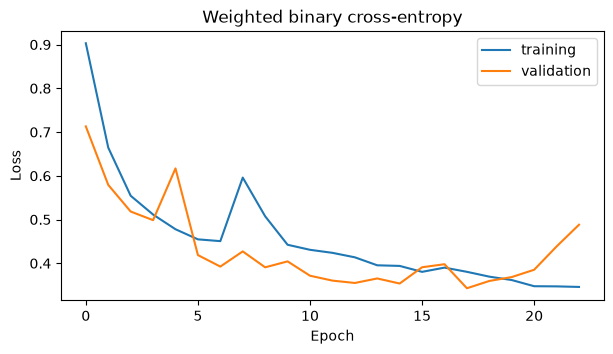

In [8]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(training_losses, label="training")
ax.plot(validation_losses, label="validation")
ax.set(title="Weighted binary cross-entropy", xlabel="Epoch", ylabel="Loss")
ax.legend()
plt.show()

## Evaluate the untouched supplied test set

The final comparison reports class-wise behavior, balanced accuracy, ROC-AUC,
and PR-AUC on the supplied test samples. These are sample-level results because
the archive has no event identifiers or timestamps.

model {
  "accuracy": 0.9348426283821093,
  "balanced_accuracy": 0.9026237720066141,
  "roc_auc": 0.9830512596050969,
  "pr_auc": 0.6571422222615371,
  "confusion_matrix": [
    [
      1673,
      115
    ],
    [
      3,
      20
    ]
  ]
}
              precision    recall  f1-score   support

           0      0.998     0.936     0.966      1788
           1      0.148     0.870     0.253        23

    accuracy                          0.935      1811
   macro avg      0.573     0.903     0.610      1811
weighted avg      0.987     0.935     0.957      1811



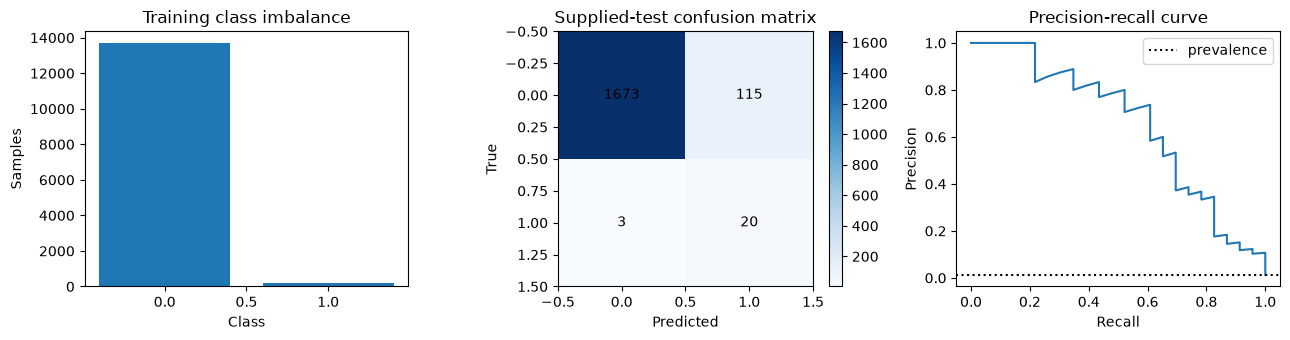

HELIO_RESULT {"balanced_accuracy": 0.9026237720066141, "majority_balanced_accuracy": 0.5, "pr_auc": 0.6571422222615371, "prediction_shape": [1811], "roc_auc": 0.9830512596050969}


In [9]:
model_evidence = classification_evidence(y_test, probabilities, "model")
matrix = np.asarray(model_evidence["confusion_matrix"])
precision, recall, _ = precision_recall_curve(y_test, probabilities)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
axes[0].bar([0, 1], np.bincount(y_train, minlength=2))
axes[0].set(title="Training class imbalance", xlabel="Class", ylabel="Samples")
image = axes[1].imshow(matrix, cmap="Blues")
for (row, column), value in np.ndenumerate(matrix):
    axes[1].text(column, row, str(value), ha="center", va="center")
axes[1].set(title="Supplied-test confusion matrix", xlabel="Predicted", ylabel="True")
fig.colorbar(image, ax=axes[1], fraction=0.046)
axes[2].plot(recall, precision)
axes[2].axhline(y_test.mean(), linestyle=":", color="black", label="prevalence")
axes[2].set(title="Precision-recall curve", xlabel="Recall", ylabel="Precision")
axes[2].legend()
plt.tight_layout()
plt.show()

print(
    "HELIO_RESULT "
    + json.dumps(
        {
            "balanced_accuracy": model_evidence["balanced_accuracy"],
            "majority_balanced_accuracy": majority_evidence["balanced_accuracy"],
            "roc_auc": model_evidence["roc_auc"],
            "pr_auc": model_evidence["pr_auc"],
            "prediction_shape": list(probabilities.shape),
        },
        sort_keys=True,
    )
)
assert probabilities.shape == y_test.shape
assert np.isfinite(probabilities).all()